# Model Representation — Linear Regression with One Variable

**Goal:** Implement and build intuition for the linear regression model
$$f_{w,b}(x) = wx + b$$

Instead of the course's house-size-vs-price example, we'll use a dataset of
**years of experience vs. salary**. Same concept, different problem — this
keeps the project genuinely yours rather than a copy of the lab.

We will:
1. Load and visualize the data
2. Implement `f_w,b(x)` from scratch (in `model.py`)
3. Manually try a few different `(w, b)` pairs and see how the line fits
4. Compute the cost for each guess, to set up intuition for the next topic
   (Cost Function), where we'll *automate* finding the best `w, b`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from model import compute_model_output, compute_cost

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load the data

In [2]:
df = pd.read_csv('data.csv')
x_train = df['years_experience'].values
y_train = df['salary_in_1000s'].values

m = x_train.shape[0]
print(f"Number of training examples (m): {m}")
df.head()

Number of training examples (m): 30


,years_experience,salary_in_1000s
0,0.7,32.5
1,0.9,39.2
2,1.1,35.9
3,1.8,39.2
4,2.0,38.6


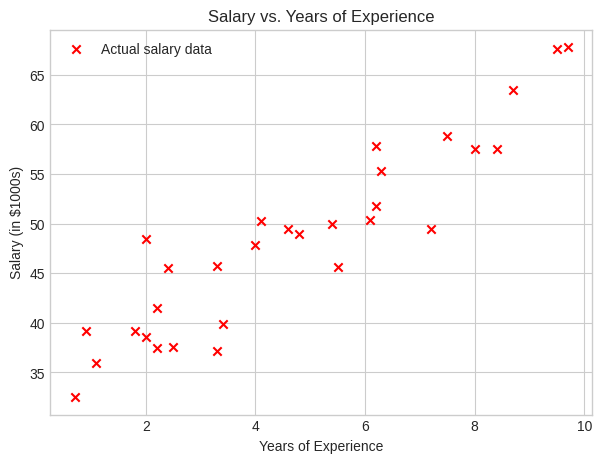

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(x_train, y_train, marker='x', c='red', label='Actual salary data')
plt.title("Salary vs. Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (in $1000s)")
plt.legend()
plt.savefig('raw_data.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. The model: $f_{w,b}(x) = wx + b$

`w` (weight) controls the slope — how much salary increases per year of experience.
`b` (bias) controls the intercept — the predicted salary at 0 years of experience.

Let's try a first guess and see how it looks against the data.

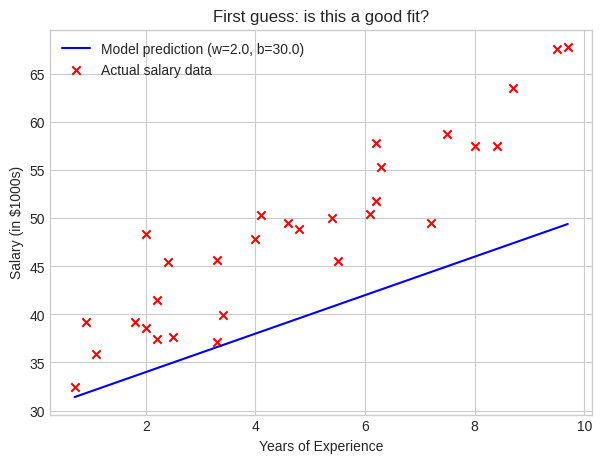

Cost for w=2.0, b=30.0: 51.74


In [4]:
w = 2.0
b = 30.0

f_wb = compute_model_output(x_train, w, b)

plt.figure(figsize=(7, 5))
plt.plot(x_train, f_wb, c='blue', label=f'Model prediction (w={w}, b={b})')
plt.scatter(x_train, y_train, marker='x', c='red', label='Actual salary data')
plt.title("First guess: is this a good fit?")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (in $1000s)")
plt.legend()
plt.show()

cost = compute_cost(x_train, y_train, w, b)
print(f"Cost for w={w}, b={b}: {cost:.2f}")

Not a terrible fit, but clearly not the best one either. Let's try a few
more `(w, b)` combinations and compare them using the cost — a lower cost
means a better fit.

w= 2.0, b= 30.0  ->  cost = 51.74
w= 3.0, b= 35.0  ->  cost = 6.82
w= 4.0, b= 25.0  ->  cost = 18.83
w= 2.5, b= 33.0  ->  cost = 14.81


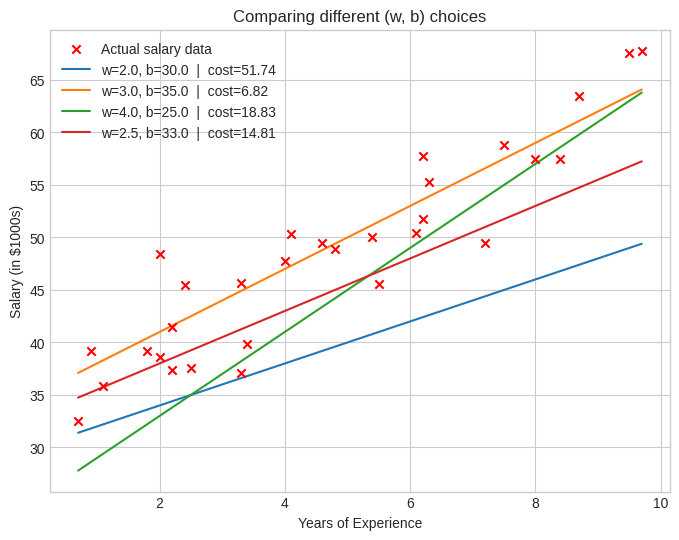

In [5]:
candidates = [
    (2.0, 30.0),
    (3.0, 35.0),
    (4.0, 25.0),
    (2.5, 33.0),
]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x_train, y_train, marker='x', c='red', label='Actual salary data', zorder=5)

for w, b in candidates:
    f_wb = compute_model_output(x_train, w, b)
    cost = compute_cost(x_train, y_train, w, b)
    ax.plot(x_train, f_wb, label=f'w={w}, b={b}  |  cost={cost:.2f}')
    print(f"w={w:>4}, b={b:>5}  ->  cost = {cost:.2f}")

ax.set_title("Comparing different (w, b) choices")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Salary (in $1000s)")
ax.legend()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Interactive exploration (optional — run in Jupyter/Colab)

Use the sliders below to manually search for the (w, b) pair that
minimizes the cost. This is the exact problem **Gradient Descent** solves
automatically in a later lab — for now, the goal is just to *feel* how
changing w and b changes the fit and the cost.

In [6]:
from ipywidgets import interact, FloatSlider

def plot_fit(w=3.0, b=35.0):
    f_wb = compute_model_output(x_train, w, b)
    cost = compute_cost(x_train, y_train, w, b)

    plt.figure(figsize=(7, 5))
    plt.scatter(x_train, y_train, marker='x', c='red', label='Actual salary data')
    plt.plot(x_train, f_wb, c='blue', label=f'f(x) = {w:.1f}x + {b:.1f}')
    plt.title(f"Cost: {cost:.2f}")
    plt.xlabel("Years of Experience")
    plt.ylabel("Salary (in $1000s)")
    plt.ylim(20, 70)
    plt.legend()
    plt.show()

interact(plot_fit,
         w=FloatSlider(min=-2, max=8, step=0.1, value=3.0),
         b=FloatSlider(min=10, max=60, step=1, value=35.0));

interactive(children=(FloatSlider(value=3.0, description='w', max=8.0, min=-2.0), FloatSlider(value=35.0, desc…

## 4. Make a prediction

Once you've found a `(w, b)` pair you're happy with, use the model to
predict the salary for someone with, say, 7.5 years of experience.

In [7]:
w_final, b_final = 3.0, 35.0  # update with your best manual guess

years = 7.5
predicted_salary = w_final * years + b_final
print(f"Predicted salary at {years} years of experience: ${predicted_salary:.1f}k")

Predicted salary at 7.5 years of experience: $57.5k


## Takeaways

- `f_w,b(x) = wx + b` is the model: given parameters `w` and `b`, it
  produces a prediction for any input `x`.
- Different `(w, b)` pairs fit the data differently — and we can quantify
  "how well" using the cost function.
- Right now we found `w` and `b` by manual trial and error. **Next up:**
  the Cost Function lab formalizes this comparison, and the Gradient
  Descent lab automates the search so we never have to guess by hand
  again.